In [ ]:
# !pip install optuna


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import joblib
import os
import time


In [ ]:
df= pd.read_csv('/content/combined_autism_data_ALL.csv')


In [ ]:
df.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F10072,F10073,F10074,F10075,F10076,F10077,F10078,F10079,F10080,output
0,285.639250,147.283009,312.509111,111.863646,245.334457,117.970432,334.493544,100.871429,181.823875,113.085003,...,149.546751,296.190552,149.546751,314.337117,154.731483,296.190552,154.731483,309.152384,163.804766,armflapping
1,373.291909,128.533153,407.445831,100.884740,347.269872,105.763872,459.489904,109.016627,324.500591,130.159530,...,286.967812,216.266866,266.008876,219.261000,285.470745,222.255133,269.003010,219.261000,288.464879,armflapping
2,268.361804,130.209595,292.540599,106.030801,232.093611,99.986102,314.704494,132.224494,177.691323,114.090399,...,293.783317,425.074605,266.996893,429.801621,296.934661,414.044901,273.299581,423.498933,295.358989,armflapping
3,372.954241,129.389033,406.056579,100.800652,345.870511,106.819258,458.719389,112.837865,321.796084,129.389033,...,290.170716,220.754622,268.414709,216.403420,288.720315,232.357826,269.865109,226.556224,284.369114,armflapping
4,341.726645,119.891422,368.148010,81.275579,311.240454,103.632120,423.023152,81.275579,297.013566,128.021073,...,320.109726,224.283186,300.523505,227.081218,317.311694,238.273344,303.321537,236.874328,314.513663,armflapping


In [ ]:
df.shape

(990, 10081)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Columns: 10081 entries, F1 to output
dtypes: float64(10080), object(1)
memory usage: 76.1+ MB


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
output,0
F10065,0
F10064,0
F10063,0
F10062,0
...,...
F6,0
F5,0
F4,0
F3,0


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['output'].unique()

array(['armflapping', 'headbanging', 'Spinning', 'toe_walking', 'pacing'],
      dtype=object)

In [ ]:
Target = {
    'armflapping':0,
        'headbanging':1,
        'Spinning':2,
    'toe_walking':3,
    'pacing':4

          }

/tmp/ipython-input-1187323991.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='output', palette='Set2')  # Change 'Set2' to any desired palette


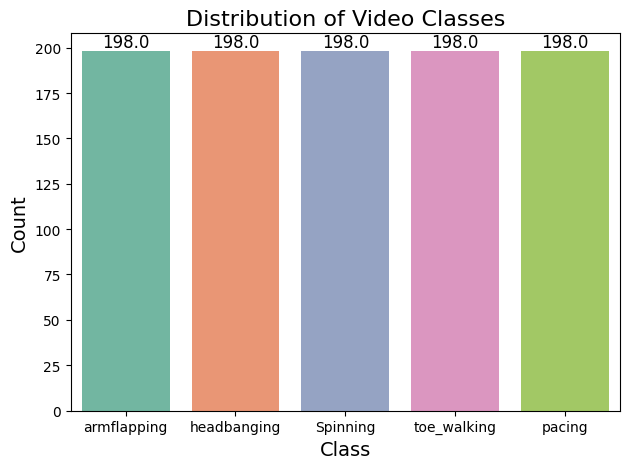

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the countplot with a custom color palette
ax = sns.countplot(data=df, x='output', palette='Set2')  # Change 'Set2' to any desired palette

# Add value annotations on top of each bar
for p in ax.patches:
    height = p.get_height()  # Get the height of the bar
    ax.annotate(
        f'{height}',  # Text to display (the count)
        (p.get_x() + p.get_width() / 2, height),  # Position of the annotation
        ha='center',  # Horizontal alignment
        va='bottom',  # Vertical alignment
        fontsize=12,  # Font size
        color='black'  # Text color
    )

# Add labels and title
plt.xlabel('Class', fontsize=14)  # X-axis label
plt.ylabel('Count', fontsize=14)  # Y-axis label
plt.title('Distribution of Video Classes', fontsize=16)  # Plot title

# Show the plot
plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()


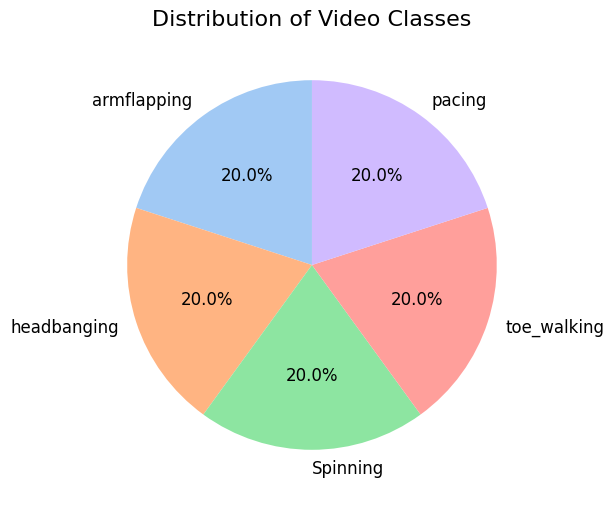

In [ ]:
# Calculate value counts for the 'output' column
counts = df['output'].value_counts()

# Create a pie chart with pastel colors
plt.figure(figsize=(8, 6))
counts.plot.pie(
    autopct='%1.1f%%',  # Add percentage display
    startangle=90,      # Start angle for better readability
    colors=sns.color_palette('pastel'),  # Use a pastel palette
    textprops={'fontsize': 12}  # Adjust font size
)

plt.title('Distribution of Video Classes', fontsize=16)
plt.ylabel('')  # Remove the y-axis label for cleaner visualization
plt.show()


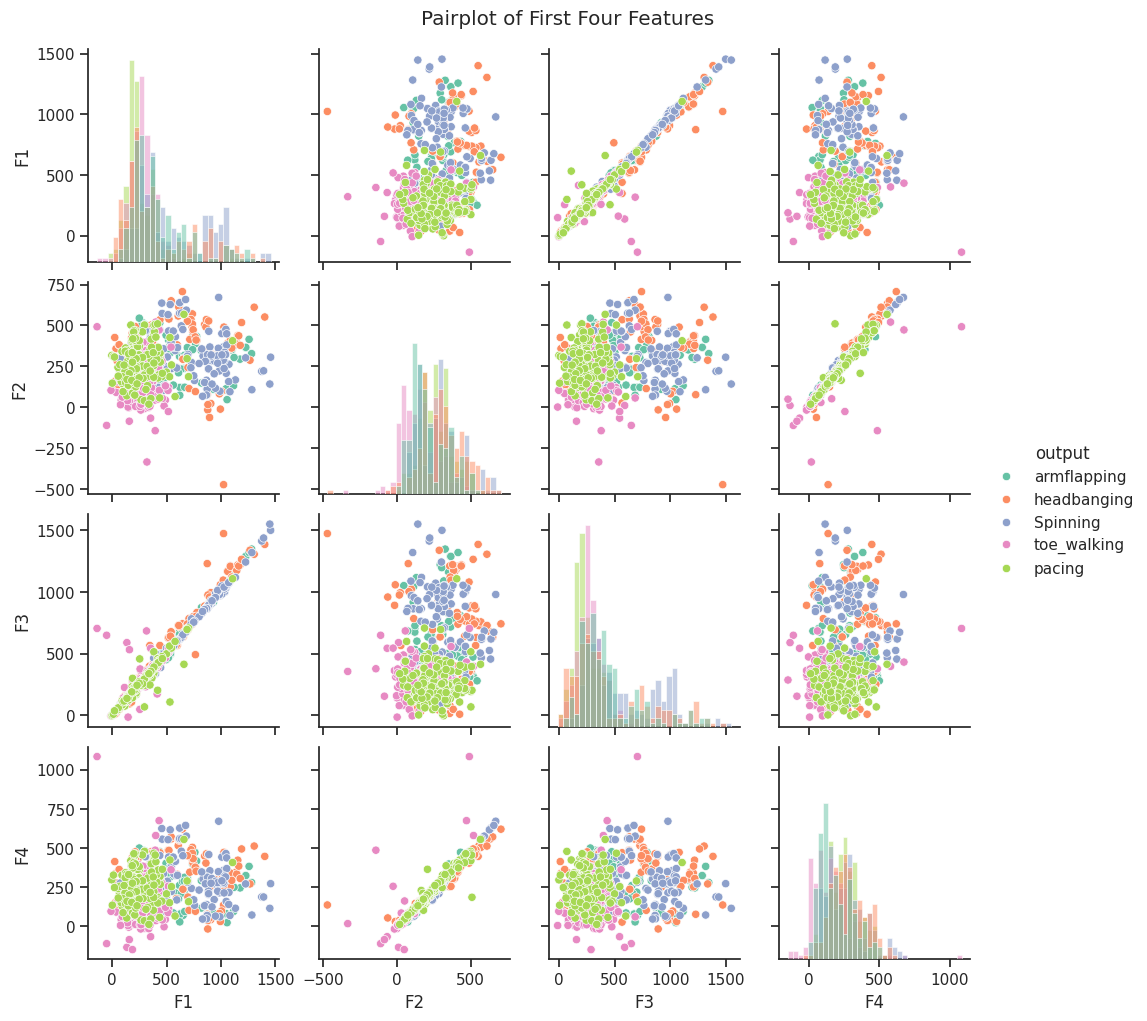

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df is your dataset and 'output' is the target column
# Select the first four features + target
pairplot_df = df[['F1', 'F2', 'F3', 'F4', 'output']]

# Create a pairplot
sns.set(style="ticks", palette="Set2")
sns.pairplot(pairplot_df, hue='output', diag_kind='hist', corner=False)
plt.suptitle('Pairplot of First Four Features', y=1.02)
plt.show()


In [ ]:
from sklearn.utils import shuffle
df = shuffle(df, random_state=42).reset_index(drop=True)


In [ ]:
df['output'] = df['output'].map(Target)
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [ ]:
X.shape,y.shape

((990, 10080), (990,))

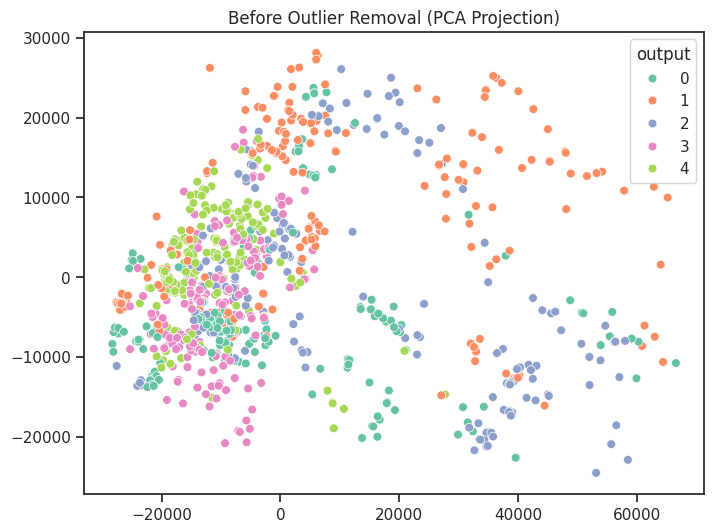

In [ ]:
from sklearn.decomposition import PCA
# ==============================
# 2️⃣ Visualize Outliers Before Removal (using PCA for 2D view)
# ==============================
pca_vis = PCA(n_components=2, random_state=42)
X_2d = pca_vis.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y, palette="Set2", s=40)
plt.title("Before Outlier Removal (PCA Projection)")
plt.show()

After outlier removal: (940, 10080)
Removed 50 outliers


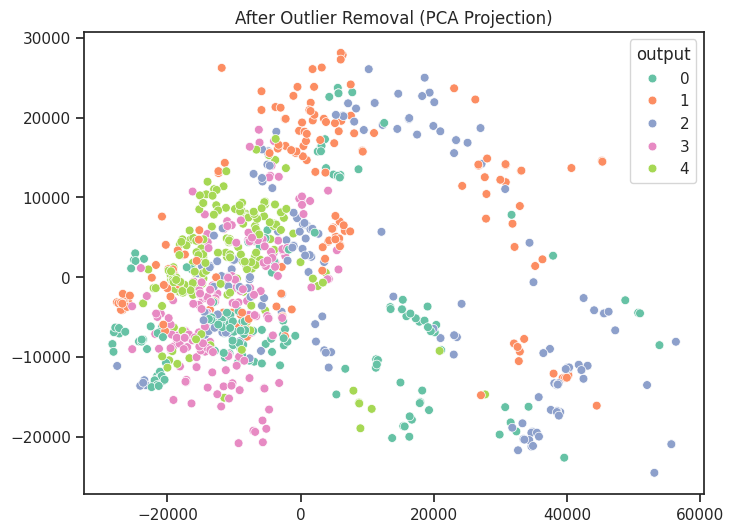

In [ ]:
from sklearn.ensemble import IsolationForest
# ================================================================
# 5️⃣ OUTLIER DETECTION AND REMOVAL
# ================================================================
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
outlier_labels = iso_forest.fit_predict(X)

inliers_mask = outlier_labels == 1
X_clean = X[inliers_mask]
y_clean = y[inliers_mask]

print(f"After outlier removal: {X_clean.shape}")
print(f"Removed {(~inliers_mask).sum()} outliers")

# Visualize after removal
X_clean_2d = pca_vis.transform(X_clean)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_clean_2d[:, 0], y=X_clean_2d[:, 1], hue=y_clean, palette="Set2", s=40)
plt.title("After Outlier Removal (PCA Projection)")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# ================================================================
# 6️⃣ SPLITTING CLEAN DATA
# ================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=100, stratify=y_clean
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train shape before outlier removal: {X_train.shape}")
print(f"Test shape (will not change): {X_test.shape}")


Train: (752, 10080), Test: (188, 10080)
Train shape before outlier removal: (752, 10080)
Test shape (will not change): (188, 10080)


/tmp/ipython-input-2215680066.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y_train_resampled, palette="Set2")


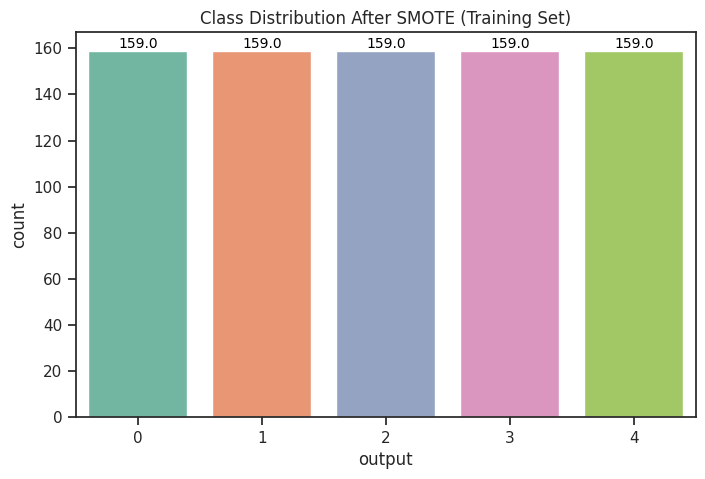

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot class distribution with counts only
plt.figure(figsize=(8,5))
ax = sns.countplot(x=y_train_resampled, palette="Set2")
plt.title("Class Distribution After SMOTE (Training Set)")

# Annotate each bar with count
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height}",  # Only count
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, color='black')

plt.show()


In [ ]:
X_train.shape ,X_test.shape, y_train.shape, y_test.shape

((752, 10080), (188, 10080), (752,), (188,))

In [ ]:
from sklearn.preprocessing import RobustScaler
# ================================================================
# 7️⃣ SCALING
# ================================================================
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nScaling complete!")


Scaling complete!


PCA Components: 41
Explained Variance: 0.9500


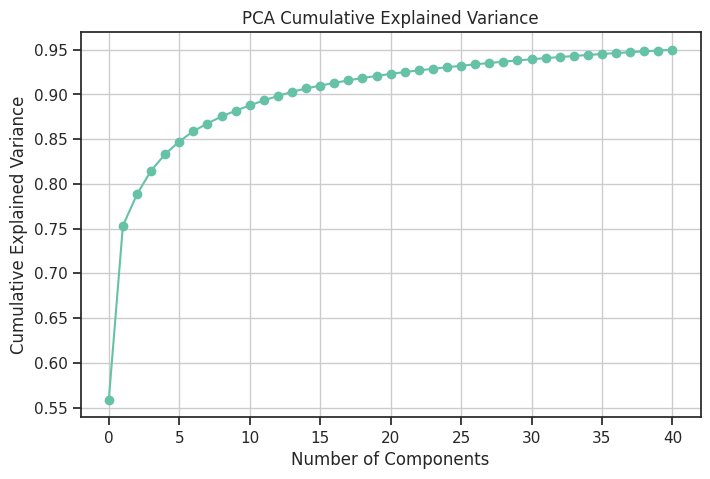

In [ ]:
from sklearn.decomposition import PCA
import joblib
# ================================================================
# 8️⃣ PCA
# ================================================================
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA Components: {pca.n_components_}")
print(f"Explained Variance: {pca.explained_variance_ratio_.sum():.4f}")

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True)
plt.show()



/tmp/ipython-input-1898404279.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y_data, palette="Set2")
/tmp/ipython-input-1898404279.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names)
/tmp/ipython-input-1898404279.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y_data, palette="Set2")
/tmp/ipython-input-1898404279.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names)
/tmp/ipython-input-1898404279.py:13: FutureWarning: 

Passing `palet

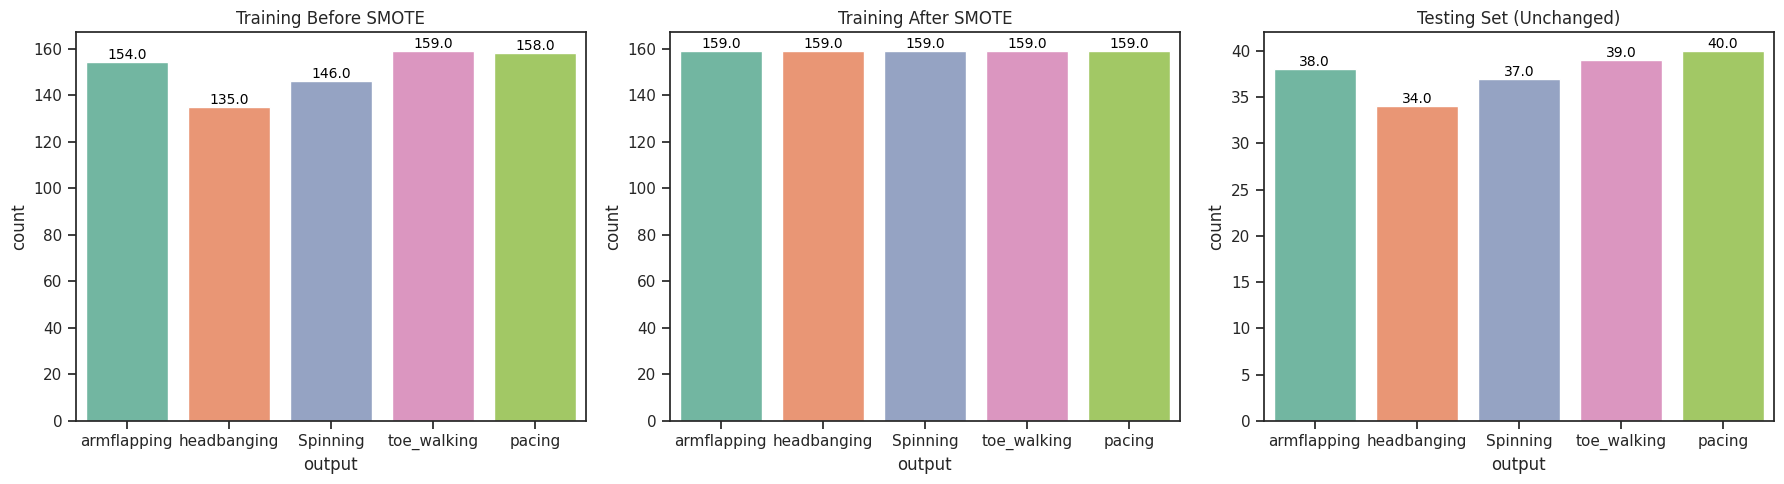

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_class_distribution(y_train, y_train_resampled, y_test, class_names=None):
    plt.figure(figsize=(18, 5))

    datasets = [("Training Before SMOTE", y_train),
                ("Training After SMOTE", y_train_resampled),
                ("Testing Set (Unchanged)", y_test)]

    for i, (title, y_data) in enumerate(datasets, 1):
        plt.subplot(1, 3, i)
        ax = sns.countplot(x=y_data, palette="Set2")
        plt.title(title)

        # Set class names on x-axis if provided
        if class_names:
            ax.set_xticklabels(class_names)

        # Annotate each bar with count only
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f"{height}",
                        (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=10, color='black')

    plt.tight_layout()
    plt.show()

# Example usage
class_names = ['armflapping', 'headbanging', 'Spinning', 'toe_walking', 'pacing']
plot_class_distribution(y_train, y_train_resampled, y_test, class_names=class_names)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.svm import  SVC
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

# Dictionary of models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000,random_state=42),
    'SGD': SGDClassifier(random_state=42),
    'K Nearest Neighbors' : KNeighborsClassifier(),
    'Support Vector Machine': SVC(probability=True ,random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Bagging': BaggingClassifier(n_jobs=-1,random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=42),
    'AdaBoosting': AdaBoostClassifier(random_state=42),
    'MLP':MLPClassifier(early_stopping=True, validation_fraction=0.1, n_iter_no_change=10, random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42,eval_metric='mlogloss')
}

In [ ]:
import time
def train_ML_algorithms(X_train_pca, y_train, X_test_pca, y_test, models):

    results = []
    models_name = []
    predictions_dict = {}

    for name, model in tqdm(models.items()):
        # Start timing for training
        train_start_time = time.time()

        # Fit the model
        model.fit(X_train_pca, y_train)

        # End timing for training
        train_end_time = time.time()
        training_time = train_end_time - train_start_time

        # Start timing for test predictions
        test_pred_start_time = time.time()

        # Test predictions
        y_test_pred = model.predict(X_test_pca)

        # End timing for test predictions
        test_pred_end_time = time.time()
        test_pred_time = test_pred_end_time - test_pred_start_time

        # Train predictions
        y_train_pred = model.predict(X_train_pca)

        # Save predictions
        predictions_dict[name] = {
            "y_train_pred": y_train_pred,
            "y_test_pred": y_test_pred
        }

        # Metrics
        accuracy_train = round(accuracy_score(y_train, y_train_pred), 3) * 100
        f1_train = round(f1_score(y_train, y_train_pred, average='weighted'), 3) * 100
        precision_train = round(precision_score(y_train, y_train_pred, average='weighted'), 3) * 100
        recall_train = round(recall_score(y_train, y_train_pred, average='weighted'), 3) * 100

        accuracy_test = round(accuracy_score(y_test, y_test_pred), 3) * 100
        f1_test = round(f1_score(y_test, y_test_pred, average='weighted'), 3) * 100
        precision_test = round(precision_score(y_test, y_test_pred, average='weighted'), 3) * 100
        recall_test = round(recall_score(y_test, y_test_pred, average='weighted'), 3) * 100

        models_name.append(name)
        results.append([
            accuracy_train, accuracy_test, precision_train, precision_test,
            recall_train, recall_test, f1_train, f1_test, training_time, test_pred_time
        ])

    # Create DataFrame for model metrics
    Model_accuracy = pd.DataFrame(
        results,
        index=models_name,
        columns=[
            'Accuracy Train', 'Accuracy Test', 'Precision Train', 'Precision Test',
            'Recall Train', 'Recall Test', 'F1 Score Train', 'F1 Score Test',
            'Training Time (s)', 'Test Prediction Time (s)'
        ]
    )
    return Model_accuracy, predictions_dict

In [ ]:
def plot_models_accuracy_scores(Model_accuracy):

    # Plot training and test prediction times
    plt.figure(figsize=(10, 6))

    # Extract time columns
    time_columns = ['Training Time (s)', 'Test Prediction Time (s)']
    time_data = Model_accuracy[time_columns]

    # Plot
    bar_width = 0.4
    index = np.arange(len(time_data))

    bars_train_time = plt.bar(index, time_data['Training Time (s)'], width=bar_width, color='skyblue', label='Training Time (s)')
    bars_test_time = plt.bar(index + bar_width, time_data['Test Prediction Time (s)'], width=bar_width, color='lightcoral', label='Test Prediction Time (s)')

    # Add values on top of bars
    for bar in bars_train_time:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, f"{bar.get_height():.5f}", ha='center', va='bottom', fontsize=8, rotation=90)
    for bar in bars_test_time:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, f"{bar.get_height():.5f}", ha='center', va='bottom', fontsize=8, rotation=90)

    # Add details
    plt.title('Training and Test Prediction Times')
    plt.xlabel('Models')
    plt.ylabel('Time (seconds)')
    plt.xticks(index + bar_width / 2, time_data.index, rotation=90)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)  # Move legend outside
    plt.tight_layout()
    # Set y-limit
    plt.ylim(0, int(time_data.max().max())+15)
    plt.show()

    # Rest of the original code for plotting accuracy, precision, recall, and F1 scores
    print("Models accuracy for each Machine Learning Algorithm")

    # Increase the width of the bars
    bar_width = 0.85  # Increase the width of the bars

    # Plotting the first 6 models
    fig, ax = plt.subplots(figsize=(14, 8))  # Increase the size of the figure
    Model_accuracy.iloc[:6,:-2].plot(kind='bar', ax=ax, width=bar_width)

    # Customizing the plot
    plt.xlabel('Model', fontsize=14)
    plt.ylabel('Scores', fontsize=14)
    plt.title('Model Accuracy Scores', fontsize=16)
    plt.xticks(rotation=45, fontsize=12)  # Rotate model names for better readability
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)  # Move legend outside
    plt.tight_layout()  # Adjust layout to fit labels

    # Set y-limit
    ax.set_ylim(0, 119)

    # Annotate each bar
    for p in ax.patches:
        height = p.get_height()

        # Adjust the annotation position to ensure it stays within bounds
        y_position = height + 0.05 if height + 0.05 <= ax.get_ylim()[1] else height - 0.05

        ax.annotate(f"{height:.1f}",
                    (p.get_x() + p.get_width() / 2, y_position),
                    ha='center', va='bottom', fontsize=12, rotation=90)  # Increase font size in annotations

    # Display the plot
    plt.show()
    print("""

    """)

    # Plotting the remaining models
    fig, ax = plt.subplots(figsize=(14, 8))  # Increase the size of the figure
    Model_accuracy.iloc[6:,:-2].plot(kind='bar', ax=ax, width=bar_width)

    # Customizing the plot
    plt.title('Model Accuracy Scores', fontsize=16)
    plt.xlabel('Model', fontsize=14)
    plt.ylabel('Scores', fontsize=14)
    plt.xticks(rotation=45, fontsize=12)  # Rotate model names for better readability
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)  # Move legend outside
    plt.tight_layout()  # Adjust layout to fit labels

    # Set y-limit
    ax.set_ylim(0, 119)

    # Annotate each bar
    for p in ax.patches:
        height = p.get_height()

        # Adjust the annotation position to ensure it stays within bounds
        y_position = height + 0.05 if height + 0.05 <= ax.get_ylim()[1] else height - 0.05

        ax.annotate(f"{height:.1f}",
                    (p.get_x() + p.get_width() / 2, y_position),
                    ha='center', va='bottom', fontsize=12, rotation=90)  # Increase font size in annotations

    # Display the plot
    plt.show()

    print("\n=== Models' Training vs. Testing Scores by Metric ===\n")

    # Group plots for Training and Testing metrics
    train_indices = list(range(0, len(Model_accuracy.columns), 2))[:-1]
    test_indices = list(range(1, len(Model_accuracy.columns), 2))[:-1]

    # Set a wider bar width
    bar_width = 0.85

    # Plot training metrics
    ax = Model_accuracy.iloc[:, train_indices].plot(
        kind='bar', figsize=(12, 6), width=bar_width,
    )

    # Set y-limit
    ax.set_ylim(0, 119)

    # Annotate each bar
    for p in ax.patches:
        height = p.get_height()

        # Adjust the annotation position to ensure it stays within bounds
        y_position = height + 0.05 if height + 0.05 <= ax.get_ylim()[1] else height - 0.05

        ax.annotate(f"{height:.1f}",
                    (p.get_x() + p.get_width() / 2, y_position),
                    ha='center', va='bottom', fontsize=10, rotation=90)

    plt.title('Training Metrics (Accuracy, Precision, Recall, F1)', fontsize=14)
    plt.xlabel('Models', fontsize=12)
    plt.ylabel('Scores', fontsize=12)
    plt.xticks(rotation=90, fontsize=10)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)  # Move legend outside
    plt.tight_layout()
    plt.show()

    # Plot testing metrics
    ax = Model_accuracy.iloc[:, test_indices].plot(
        kind='bar', figsize=(12, 6), width=bar_width,
    )

    # Set y-limit
    ax.set_ylim(0, 119)

    # Annotate each bar
    for p in ax.patches:
        height = p.get_height()

        # Adjust the annotation position to ensure it stays within bounds
        y_position = height + 0.05 if height + 0.05 <= ax.get_ylim()[1] else height - 0.05

        ax.annotate(f"{height:.1f}",
                    (p.get_x() + p.get_width() / 2, y_position),
                    ha='center', va='bottom', fontsize=10, rotation=90)

    plt.title('Testing Metrics (Accuracy, Precision, Recall, F1)', fontsize=14)
    plt.xlabel('Models', fontsize=12)
    plt.ylabel('Scores', fontsize=12)
    plt.xticks(rotation=90, fontsize=10)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)  # Move legend outside
    plt.tight_layout()
    plt.show()

    print("\n=== Individual Metric Comparisons (Training vs. Testing) ===\n")

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

    for metric in metrics:
        plt.figure(figsize=(10, 6))

        # Extract train and test columns for the metric
        metric_train = f'{metric} Train'
        metric_test = f'{metric} Test'

        # Sort by training metric for better readability
        sorted_accuracy = Model_accuracy.sort_values(by=metric_train, ascending=False)
        index = np.arange(len(sorted_accuracy))

        # Plot
        bar_width = 0.4
        bars_train = plt.bar(index, sorted_accuracy[metric_train], width=bar_width, color='skyblue', label=metric_train)
        bars_test = plt.bar(index + bar_width, sorted_accuracy[metric_test], width=bar_width, color='lightcoral', label=metric_test)

        # Add values on top of bars
        for bar in bars_train:
            plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8,rotation=90)
        for bar in bars_test:
            plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8,rotation=90)

        # Add details
        plt.title(f'Comparison of {metric} (Training vs Testing)')
        plt.xlabel('Models')
        plt.ylabel(f'{metric} Scores')
        plt.xticks(index + bar_width / 2, sorted_accuracy.index, rotation=90)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)  # Move legend outside
        plt.tight_layout()
        plt.ylim(0,119)
        plt.show()

    # Add the provided code here
    plt.show()

In [ ]:
def display_metrics(y_tain,y_test, predictions_dict):

    class_names = ['armflapping', 'headbanging', 'Spinning', 'toe_walking', 'pacing' ]


    for model_name, preds in predictions_dict.items():
        print(f"\n=== Metrics for Model: {model_name} ===")

        # Display metrics for training predictions
        print("\nTraining Metrics:")
        print("Classification Report:")
        print(classification_report(y_tain, preds["y_train_pred"], target_names=class_names))
        cm_train = confusion_matrix(y_tain, preds["y_train_pred"])
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
        plt.xlabel("Predicted Labels")
        plt.ylabel("True Labels")
        plt.title(f"Confusion Matrix Heatmap (Training - {model_name})")
        plt.show()

        # Display metrics for testing predictions
        print("\nTesting Metrics:")
        print("Classification Report:")
        print(classification_report(y_test, preds["y_test_pred"], target_names=class_names))
        cm_test = confusion_matrix(y_test, preds["y_test_pred"])
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
        plt.xlabel("Predicted Labels")
        plt.ylabel("True Labels")
        plt.title(f"Confusion Matrix Heatmap (Testing - {model_name})")
        plt.show()


In [ ]:
# import optuna
# # =========================================
# # 6️⃣ Optuna Hyperparameter Tuning (RF, SVM, MLP, XGBoost)
# # =========================================
# def optuna_tune(model_name, X_train_pca, y_train, n_trials=20):
#     skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
#     def objective(trial):
#         if model_name == 'Random Forest':
#             n_estimators = trial.suggest_int('n_estimators', 50, 300)
#             max_depth = trial.suggest_int('max_depth', 3, 20)
#             clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
#         elif model_name == 'SVM':
#             C = trial.suggest_loguniform('C', 0.1, 10)
#             gamma = trial.suggest_loguniform('gamma', 0.001, 1)
#             clf = SVC(C=C, gamma=gamma, probability=True, random_state=42)
#         elif model_name == 'MLP':
#             hidden_layer_sizes = trial.suggest_categorical('hidden_layer_sizes', [(50,), (100,), (50,50), (100,50)])
#             alpha = trial.suggest_loguniform('alpha', 0.0001, 0.01)
#             clf = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, alpha=alpha,
#                                 early_stopping=True, validation_fraction=0.1, n_iter_no_change=10, random_state=42)
#         elif model_name == 'XGBoost':
#             n_estimators = trial.suggest_int('n_estimators', 50, 300)
#             max_depth = trial.suggest_int('max_depth', 3, 20)
#             learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.3)
#             clf = xgb.XGBClassifier(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate,
#                                     random_state=42, eval_metric='mlogloss')
#         else:
#             return 0
#         f1_scores = []
#         for train_idx, val_idx in skf.split(X_train_pca, y_train):
#             X_tr, X_val = X_train_pca[train_idx], X_train_pca[val_idx]
#             y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
#             clf.fit(X_tr, y_tr)
#             y_pred = clf.predict(X_val)
#             f1_scores.append(f1_score(y_val, y_pred, average='weighted'))
#         return np.mean(f1_scores)

#     study = optuna.create_study(direction='maximize')
#     study.optimize(objective, n_trials=n_trials)
#     print(f"Best params for {model_name}: {study.best_params}")
#     if model_name == 'Random Forest':
#         best_model = RandomForestClassifier(**study.best_params, random_state=42)
#     elif model_name == 'SVM':
#         best_model = SVC(**study.best_params, probability=True, random_state=42)
#     elif model_name == 'MLP':
#         best_model = MLPClassifier(**study.best_params, early_stopping=True, validation_fraction=0.1, n_iter_no_change=10, random_state=42)
#     elif model_name == 'XGBoost':
#         best_model = xgb.XGBClassifier(**study.best_params, random_state=42, eval_metric='mlogloss')
#     return best_model

# # Tune models
# for m in ['Random Forest','SVM','MLP','XGBoost']:
#     models[m] = optuna_tune(m, X_train_scaled, y_train, n_trials=20)



In [ ]:
Model_accuracy, predictions_dict = train_ML_algorithms(X_train_pca, y_train, X_test_pca, y_test, models)


100%|██████████| 12/12 [00:27<00:00,  2.27s/it]


In [ ]:
Model_accuracy.sort_values(by='Accuracy Test',ascending=False,inplace=True)
Model_accuracy

,Accuracy Train,Accuracy Test,Precision Train,Precision Test,Recall Train,Recall Test,F1 Score Train,F1 Score Test,Training Time (s),Test Prediction Time (s)
Random Forest,100.0,97.3,100.0,97.4,100.0,97.3,100.0,97.3,1.406448,0.033219
Hist Gradient Boosting,100.0,95.7,100.0,95.8,100.0,95.7,100.0,95.7,3.145217,0.022226
XGBoost,100.0,95.7,100.0,95.9,100.0,95.7,100.0,95.7,1.171180,0.003842
Gradient Boosting,100.0,94.1,100.0,94.2,100.0,94.1,100.0,94.1,13.002371,0.005389
Bagging,99.9,91.5,99.9,91.8,99.9,91.5,99.9,91.4,4.947653,0.030931
MLP,93.9,88.3,93.9,88.4,93.9,88.3,93.9,88.3,0.474491,0.000883
K Nearest Neighbors,94.8,87.2,94.8,87.3,94.8,87.2,94.8,87.2,0.001155,0.003631
Decision Tree,100.0,78.7,100.0,79.2,100.0,78.7,100.0,78.7,0.054477,0.000659
Support Vector Machine,81.4,77.1,82.9,78.1,81.4,77.1,81.5,77.4,0.292726,0.016071
Logistic Regression,81.0,76.1,81.2,76.2,81.0,76.1,81.0,76.1,1.233270,0.000520


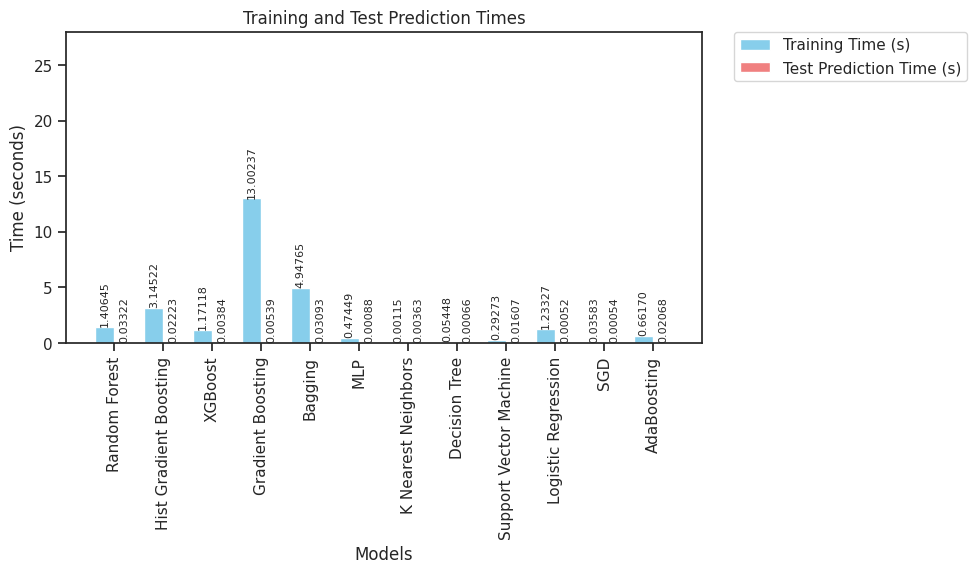

Models accuracy for each Machine Learning Algorithm


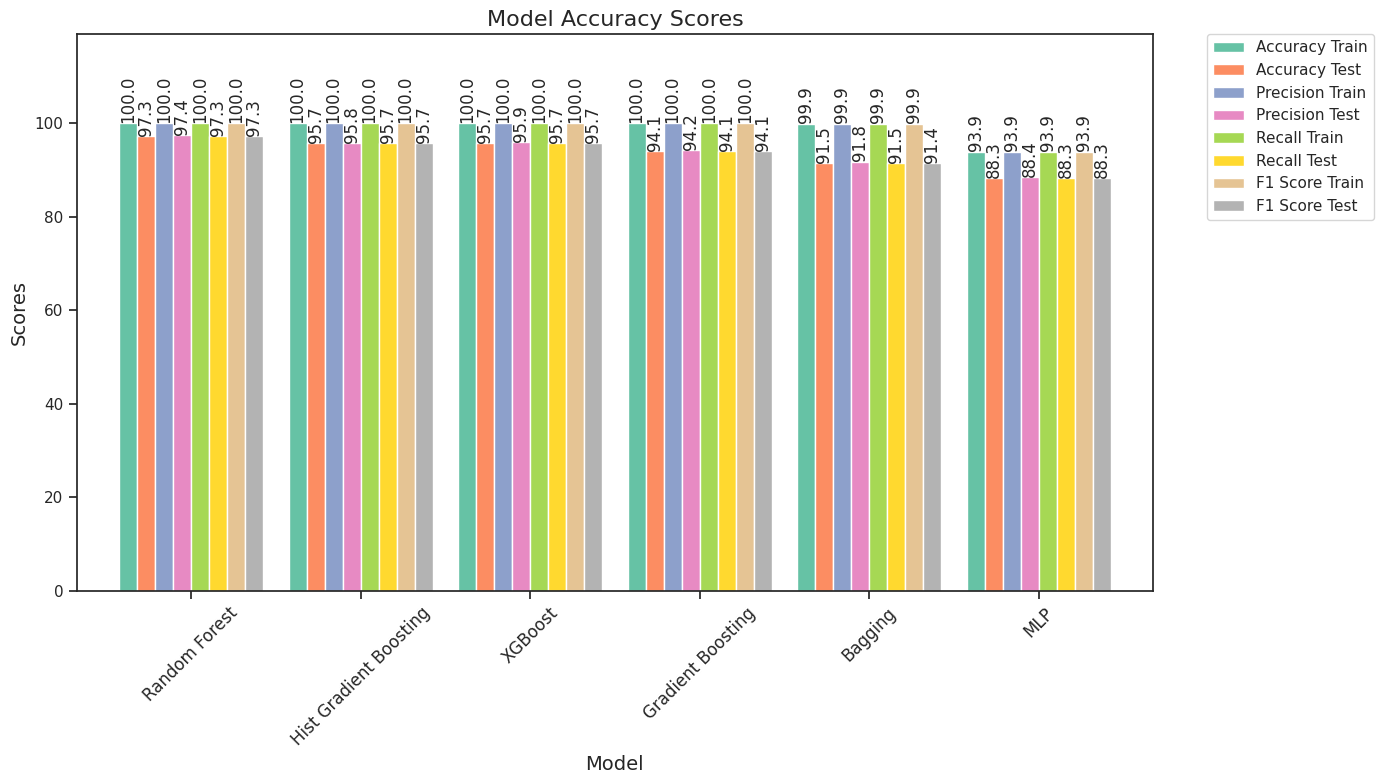

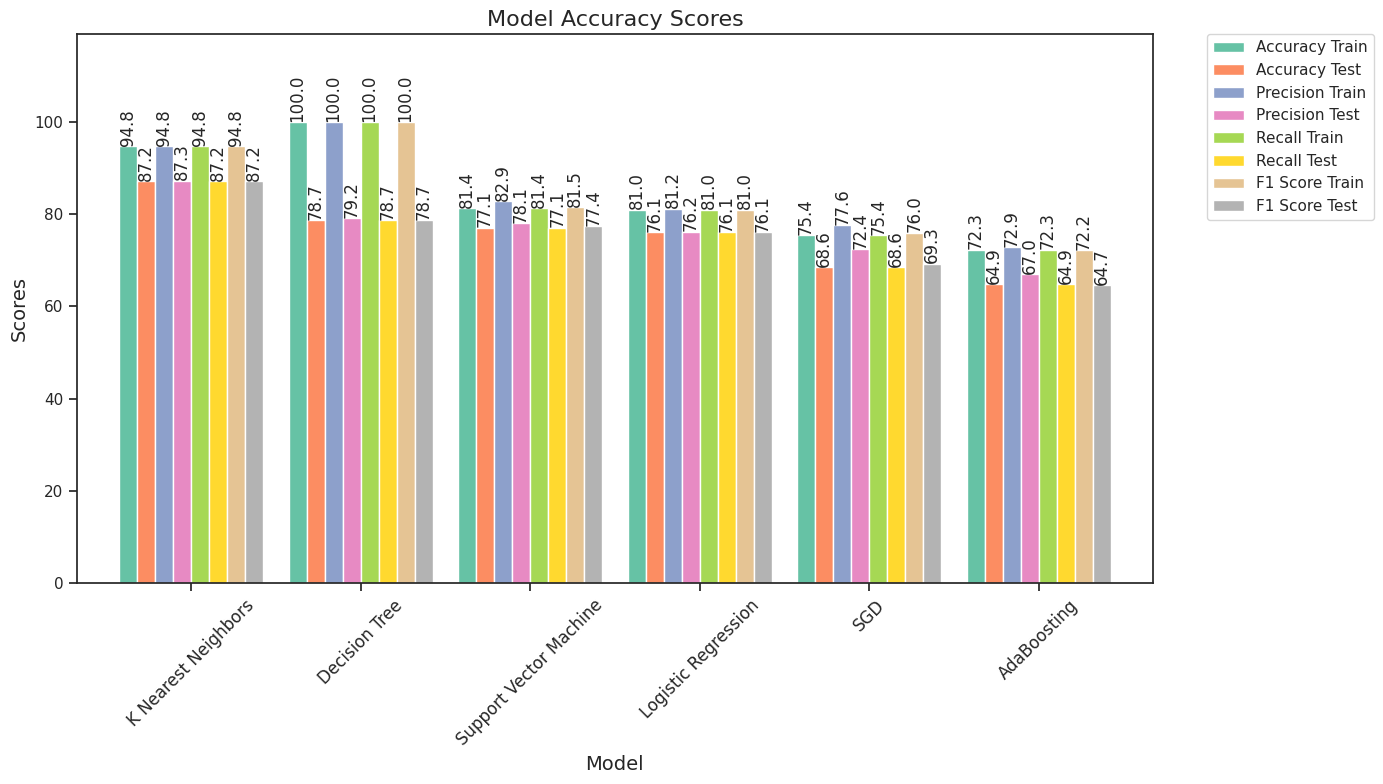


=== Models' Training vs. Testing Scores by Metric ===



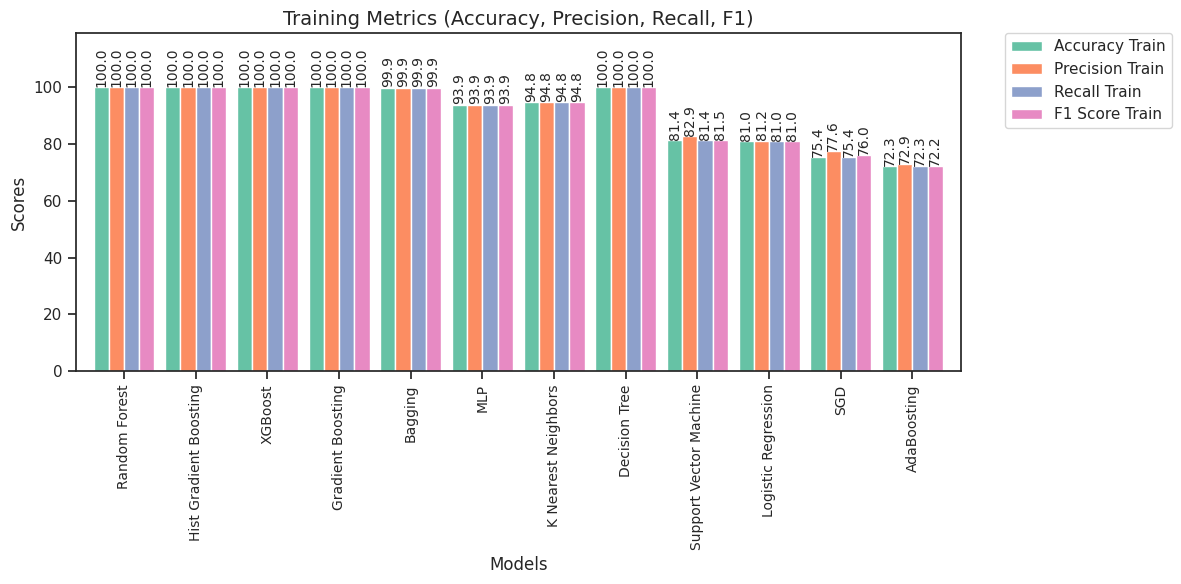

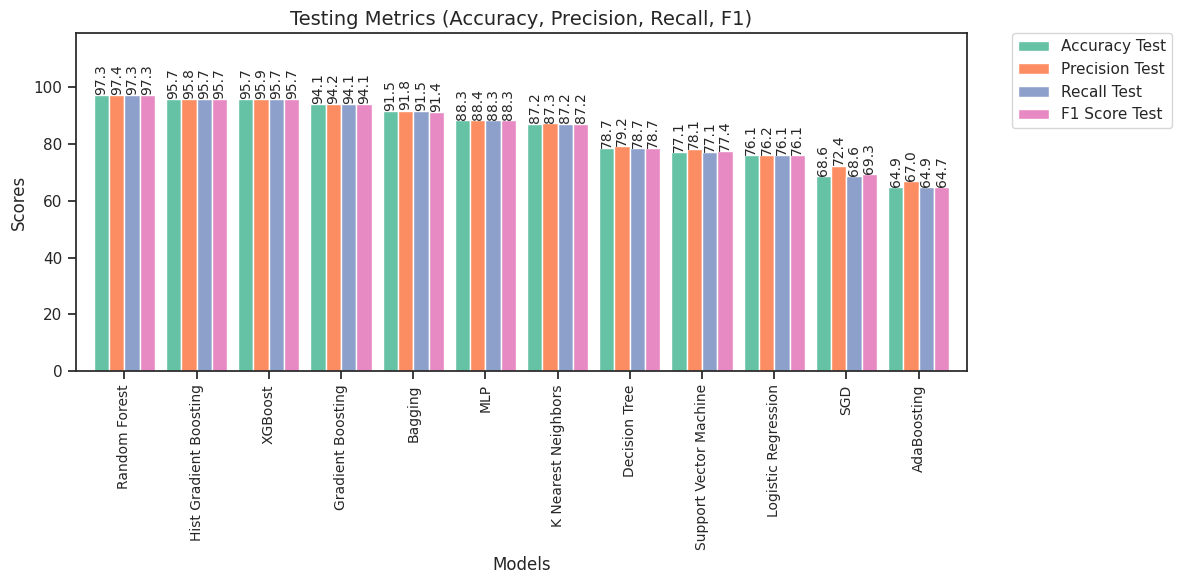


=== Individual Metric Comparisons (Training vs. Testing) ===



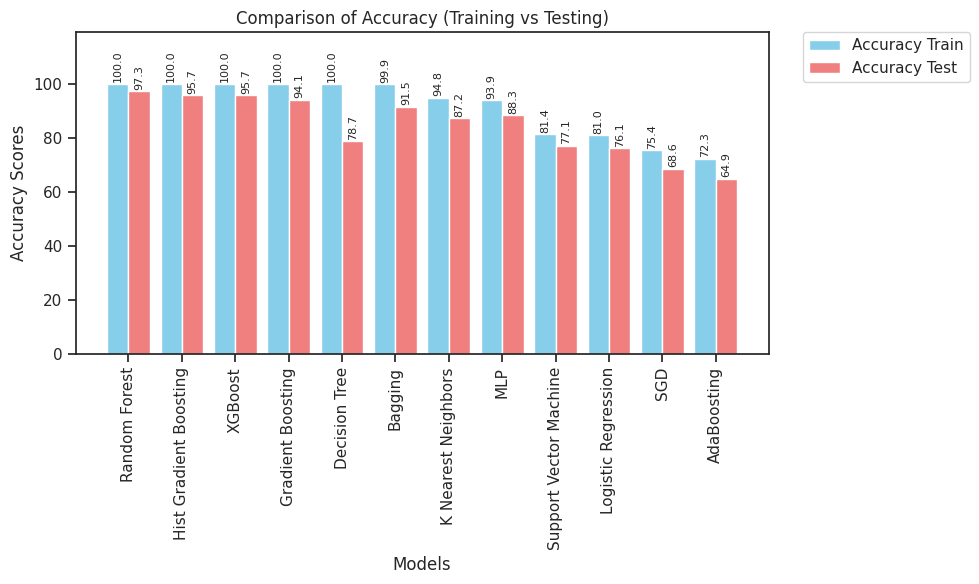

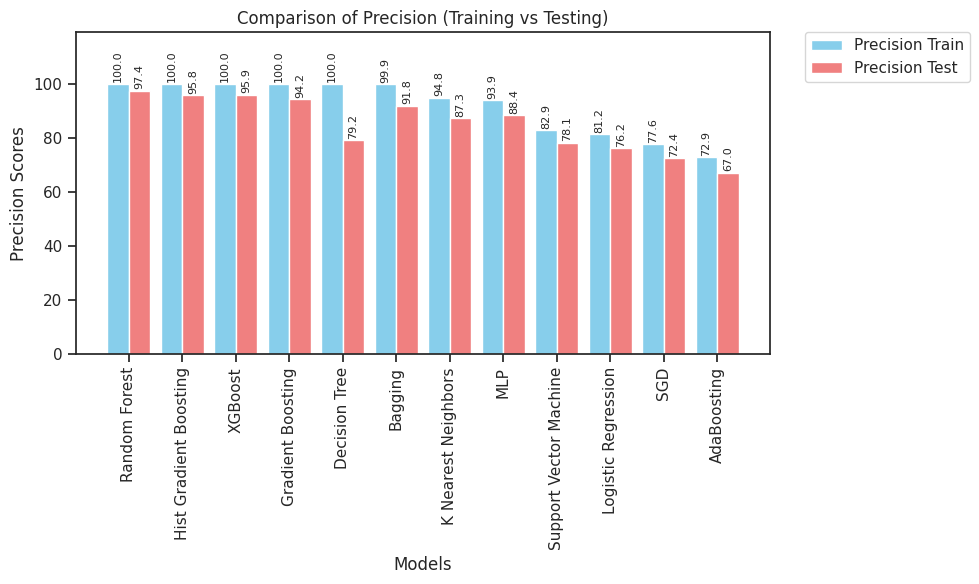

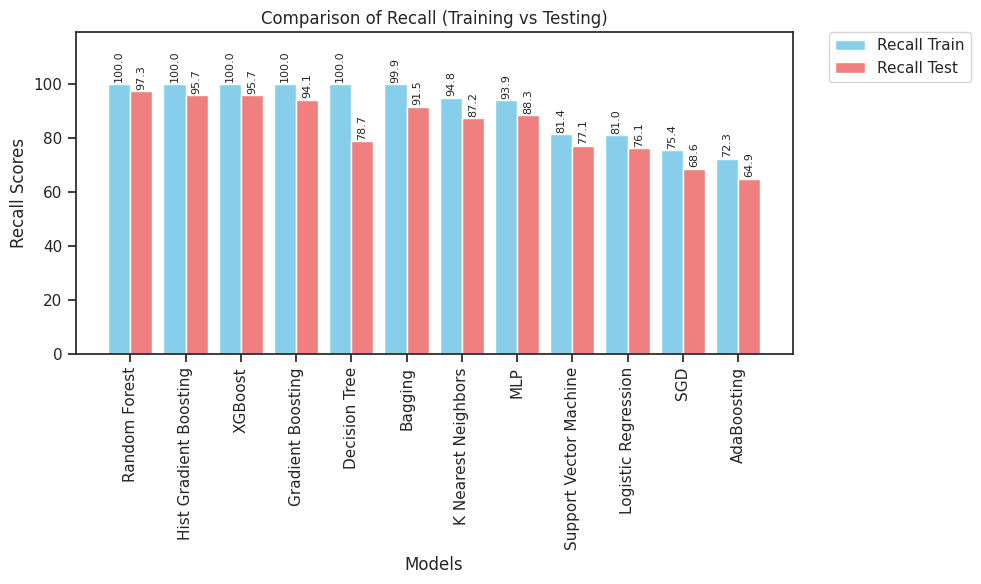

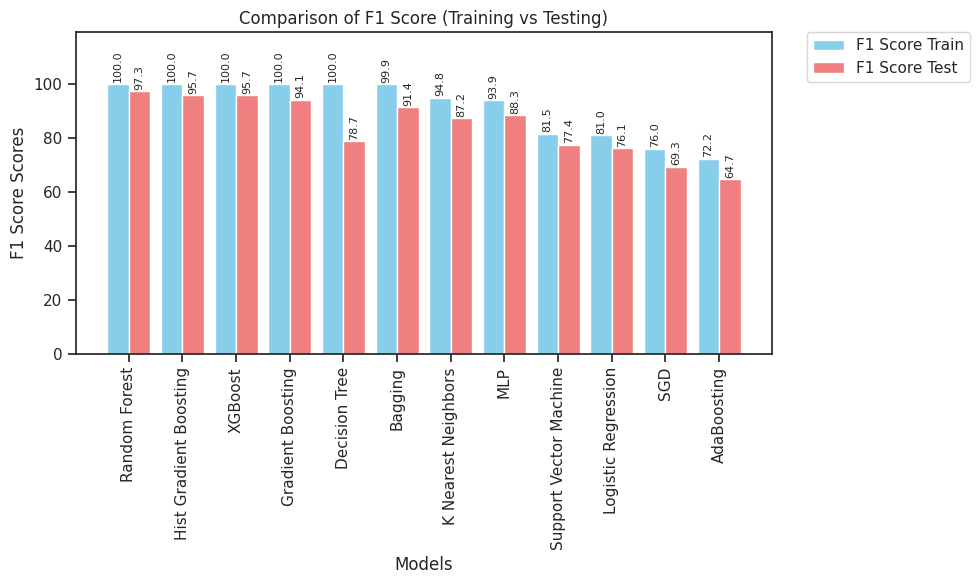

In [ ]:
plot_models_accuracy_scores(Model_accuracy)


=== Metrics for Model: Logistic Regression ===

Training Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.82      0.85      0.84       154
 headbanging       0.84      0.73      0.78       135
    Spinning       0.83      0.79      0.81       146
 toe_walking       0.83      0.84      0.83       159
      pacing       0.74      0.83      0.78       158

    accuracy                           0.81       752
   macro avg       0.81      0.81      0.81       752
weighted avg       0.81      0.81      0.81       752



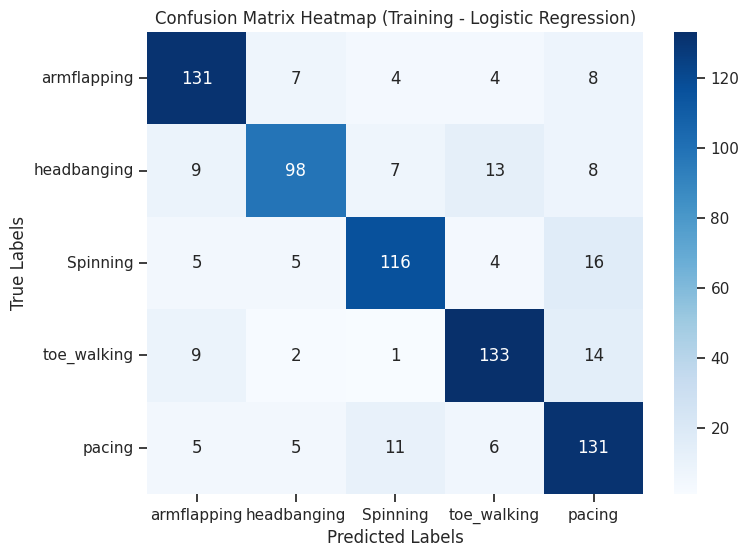


Testing Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.76      0.74      0.75        38
 headbanging       0.81      0.85      0.83        34
    Spinning       0.68      0.73      0.70        37
 toe_walking       0.84      0.79      0.82        39
      pacing       0.74      0.70      0.72        40

    accuracy                           0.76       188
   macro avg       0.76      0.76      0.76       188
weighted avg       0.76      0.76      0.76       188



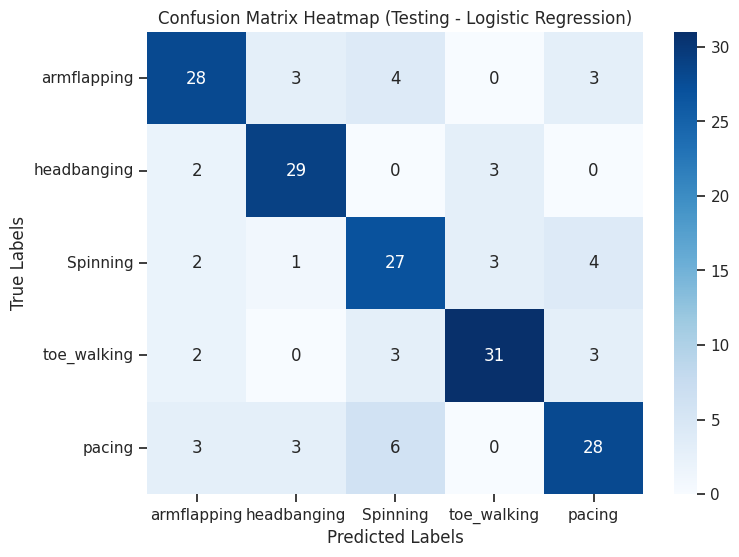


=== Metrics for Model: SGD ===

Training Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.85      0.75      0.79       154
 headbanging       0.54      0.76      0.63       135
    Spinning       0.82      0.77      0.80       146
 toe_walking       0.82      0.80      0.81       159
      pacing       0.82      0.69      0.75       158

    accuracy                           0.75       752
   macro avg       0.77      0.75      0.76       752
weighted avg       0.78      0.75      0.76       752



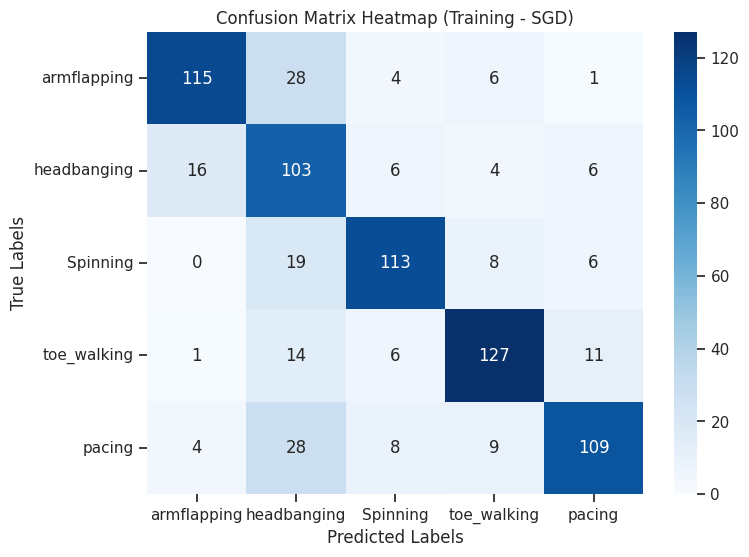


Testing Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.64      0.61      0.62        38
 headbanging       0.47      0.74      0.57        34
    Spinning       0.75      0.81      0.78        37
 toe_walking       0.93      0.72      0.81        39
      pacing       0.79      0.57      0.67        40

    accuracy                           0.69       188
   macro avg       0.72      0.69      0.69       188
weighted avg       0.72      0.69      0.69       188



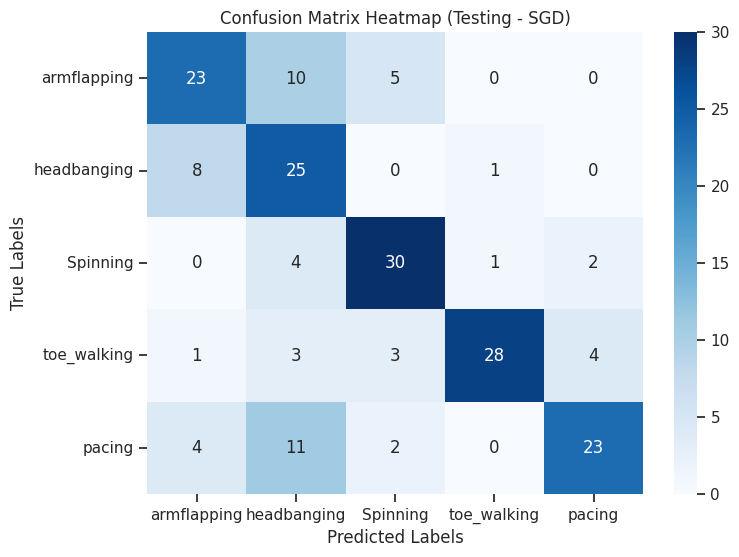


=== Metrics for Model: K Nearest Neighbors ===

Training Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.94      0.93      0.93       154
 headbanging       0.94      0.98      0.96       135
    Spinning       0.96      0.94      0.95       146
 toe_walking       0.94      0.96      0.95       159
      pacing       0.96      0.94      0.95       158

    accuracy                           0.95       752
   macro avg       0.95      0.95      0.95       752
weighted avg       0.95      0.95      0.95       752



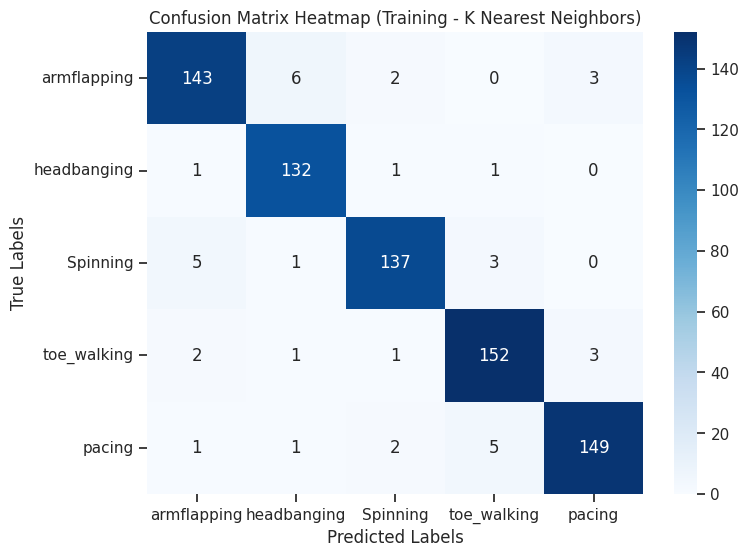


Testing Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.84      0.84      0.84        38
 headbanging       0.94      0.91      0.93        34
    Spinning       0.86      0.84      0.85        37
 toe_walking       0.86      0.82      0.84        39
      pacing       0.86      0.95      0.90        40

    accuracy                           0.87       188
   macro avg       0.87      0.87      0.87       188
weighted avg       0.87      0.87      0.87       188



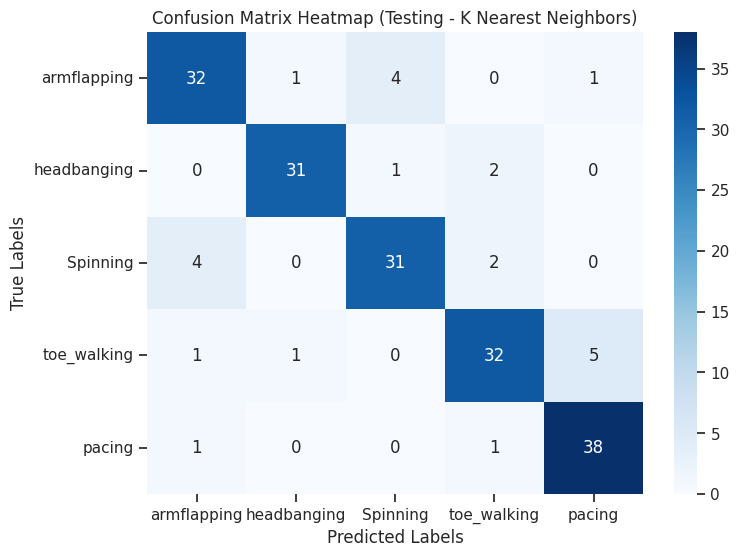


=== Metrics for Model: Support Vector Machine ===

Training Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.83      0.88      0.86       154
 headbanging       0.94      0.72      0.82       135
    Spinning       0.94      0.78      0.85       146
 toe_walking       0.76      0.82      0.79       159
      pacing       0.70      0.85      0.77       158

    accuracy                           0.81       752
   macro avg       0.83      0.81      0.82       752
weighted avg       0.83      0.81      0.82       752



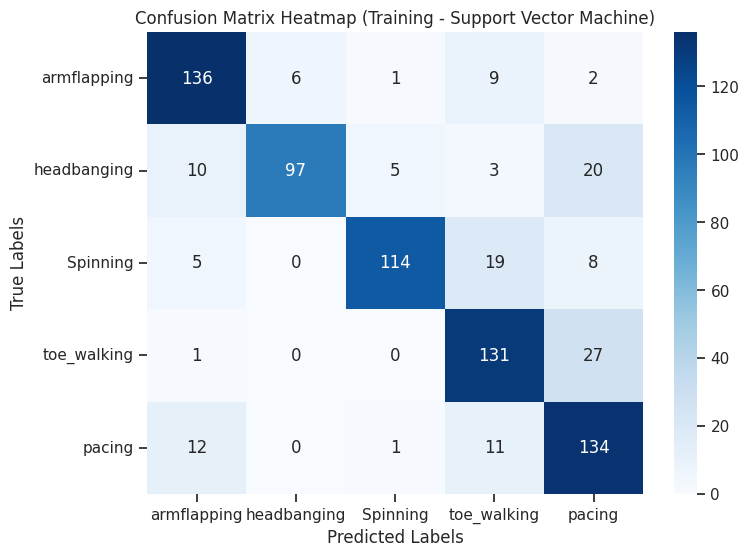


Testing Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.78      0.76      0.77        38
 headbanging       0.87      0.76      0.81        34
    Spinning       0.88      0.78      0.83        37
 toe_walking       0.74      0.74      0.74        39
      pacing       0.65      0.80      0.72        40

    accuracy                           0.77       188
   macro avg       0.79      0.77      0.78       188
weighted avg       0.78      0.77      0.77       188



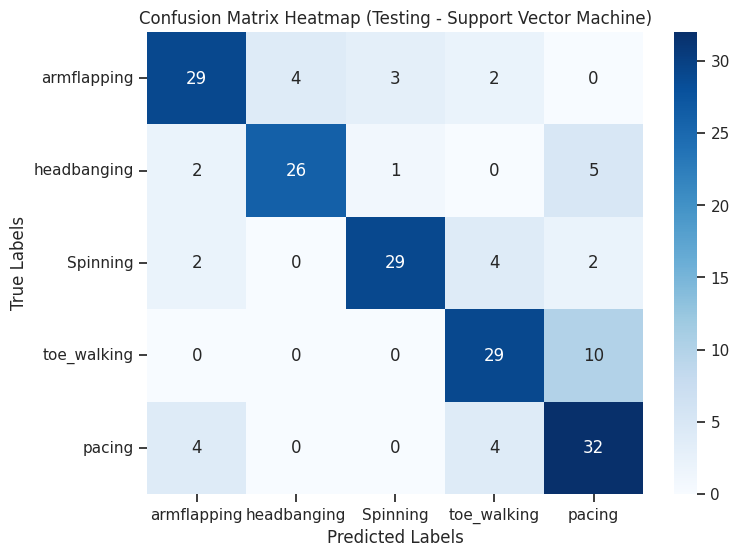


=== Metrics for Model: Decision Tree ===

Training Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       1.00      1.00      1.00       154
 headbanging       1.00      1.00      1.00       135
    Spinning       1.00      1.00      1.00       146
 toe_walking       1.00      1.00      1.00       159
      pacing       1.00      1.00      1.00       158

    accuracy                           1.00       752
   macro avg       1.00      1.00      1.00       752
weighted avg       1.00      1.00      1.00       752



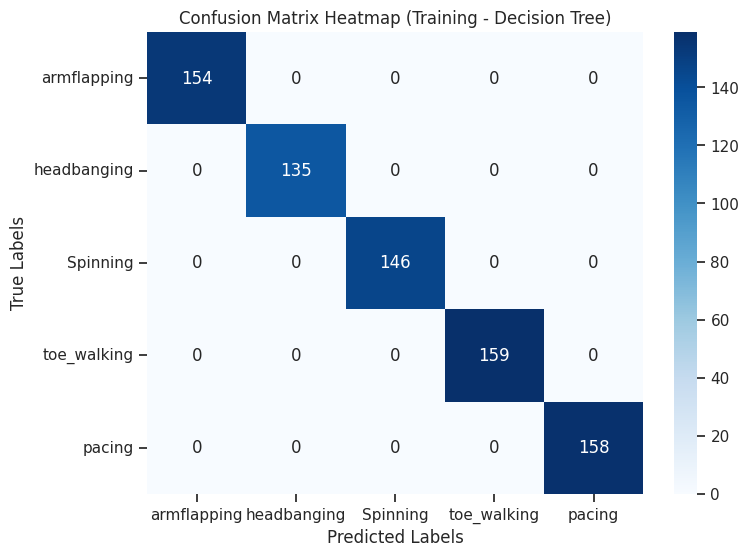


Testing Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.76      0.89      0.82        38
 headbanging       0.89      0.74      0.81        34
    Spinning       0.82      0.84      0.83        37
 toe_walking       0.72      0.72      0.72        39
      pacing       0.79      0.75      0.77        40

    accuracy                           0.79       188
   macro avg       0.79      0.79      0.79       188
weighted avg       0.79      0.79      0.79       188



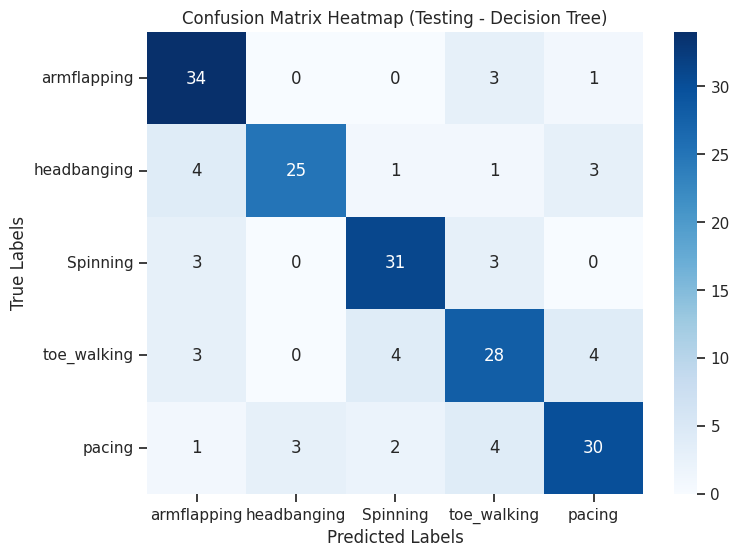


=== Metrics for Model: Random Forest ===

Training Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       1.00      1.00      1.00       154
 headbanging       1.00      1.00      1.00       135
    Spinning       1.00      1.00      1.00       146
 toe_walking       1.00      1.00      1.00       159
      pacing       1.00      1.00      1.00       158

    accuracy                           1.00       752
   macro avg       1.00      1.00      1.00       752
weighted avg       1.00      1.00      1.00       752



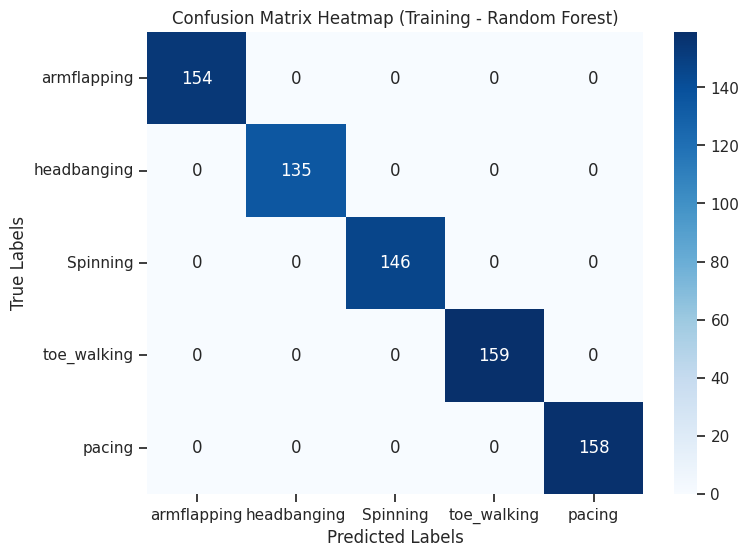


Testing Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       1.00      0.97      0.99        38
 headbanging       0.94      1.00      0.97        34
    Spinning       0.97      1.00      0.99        37
 toe_walking       0.97      0.92      0.95        39
      pacing       0.97      0.97      0.97        40

    accuracy                           0.97       188
   macro avg       0.97      0.97      0.97       188
weighted avg       0.97      0.97      0.97       188



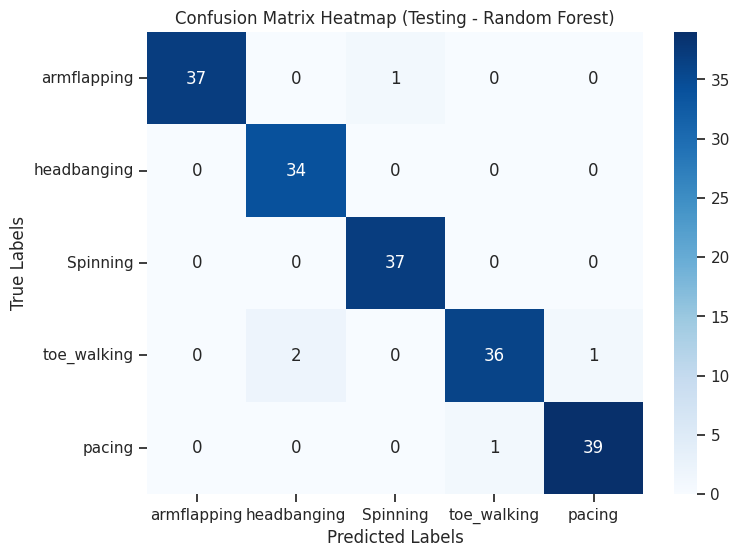


=== Metrics for Model: Bagging ===

Training Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       1.00      1.00      1.00       154
 headbanging       1.00      1.00      1.00       135
    Spinning       1.00      1.00      1.00       146
 toe_walking       0.99      1.00      1.00       159
      pacing       1.00      0.99      1.00       158

    accuracy                           1.00       752
   macro avg       1.00      1.00      1.00       752
weighted avg       1.00      1.00      1.00       752



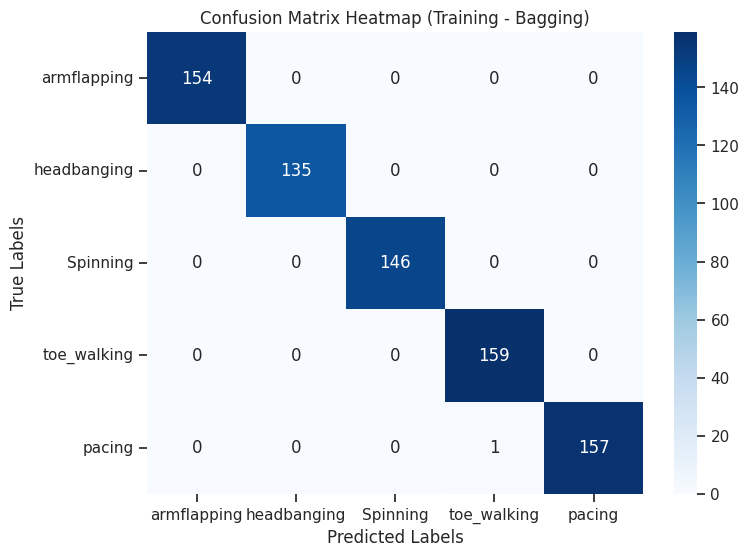


Testing Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.86      0.97      0.91        38
 headbanging       0.89      0.91      0.90        34
    Spinning       0.93      1.00      0.96        37
 toe_walking       0.97      0.85      0.90        39
      pacing       0.94      0.85      0.89        40

    accuracy                           0.91       188
   macro avg       0.92      0.92      0.91       188
weighted avg       0.92      0.91      0.91       188



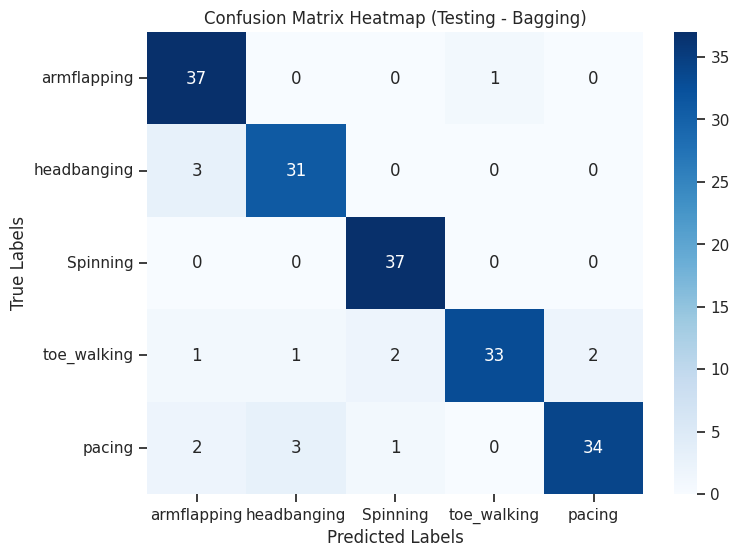


=== Metrics for Model: Gradient Boosting ===

Training Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       1.00      1.00      1.00       154
 headbanging       1.00      1.00      1.00       135
    Spinning       1.00      1.00      1.00       146
 toe_walking       1.00      1.00      1.00       159
      pacing       1.00      1.00      1.00       158

    accuracy                           1.00       752
   macro avg       1.00      1.00      1.00       752
weighted avg       1.00      1.00      1.00       752



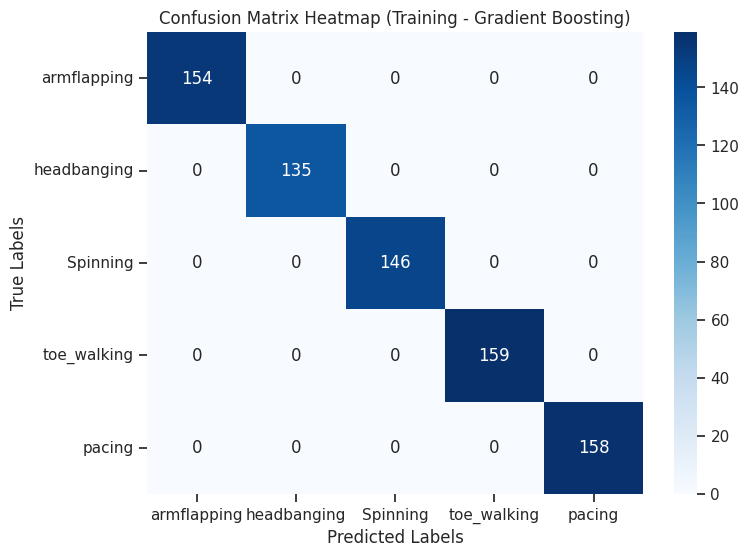


Testing Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.97      0.95      0.96        38
 headbanging       0.97      1.00      0.99        34
    Spinning       0.90      0.95      0.92        37
 toe_walking       0.92      0.90      0.91        39
      pacing       0.95      0.93      0.94        40

    accuracy                           0.94       188
   macro avg       0.94      0.94      0.94       188
weighted avg       0.94      0.94      0.94       188



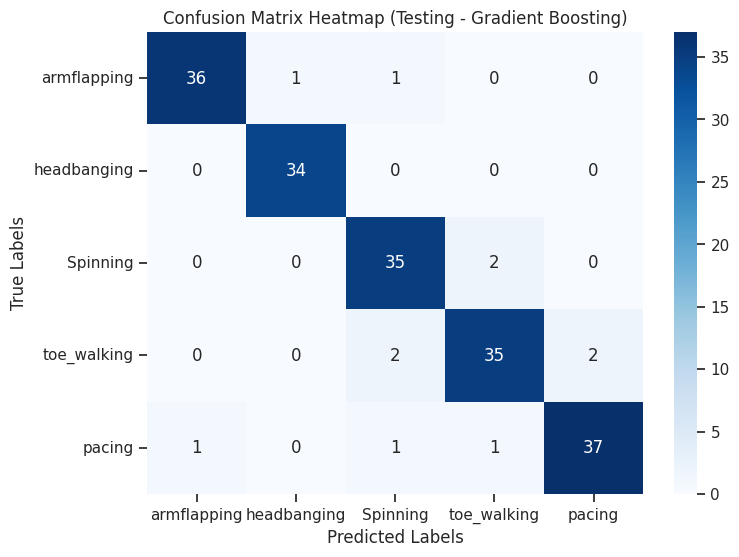


=== Metrics for Model: Hist Gradient Boosting ===

Training Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       1.00      1.00      1.00       154
 headbanging       1.00      1.00      1.00       135
    Spinning       1.00      1.00      1.00       146
 toe_walking       1.00      1.00      1.00       159
      pacing       1.00      1.00      1.00       158

    accuracy                           1.00       752
   macro avg       1.00      1.00      1.00       752
weighted avg       1.00      1.00      1.00       752



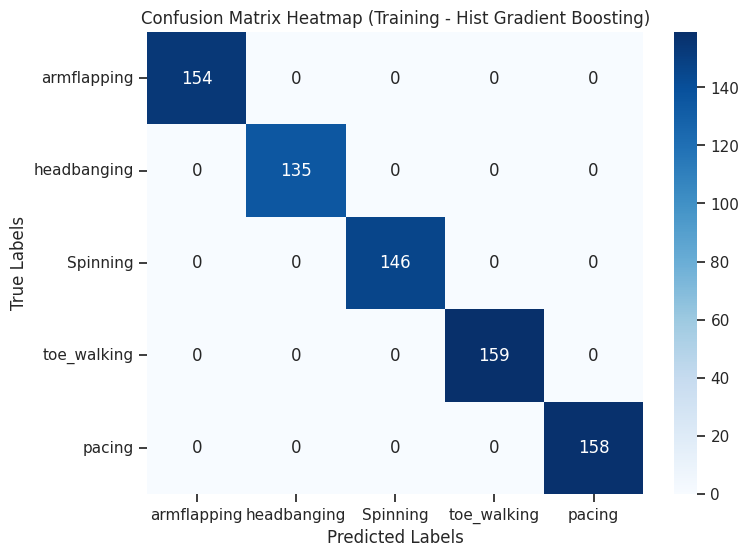


Testing Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       1.00      0.95      0.97        38
 headbanging       0.97      1.00      0.99        34
    Spinning       0.95      0.97      0.96        37
 toe_walking       0.92      0.92      0.92        39
      pacing       0.95      0.95      0.95        40

    accuracy                           0.96       188
   macro avg       0.96      0.96      0.96       188
weighted avg       0.96      0.96      0.96       188



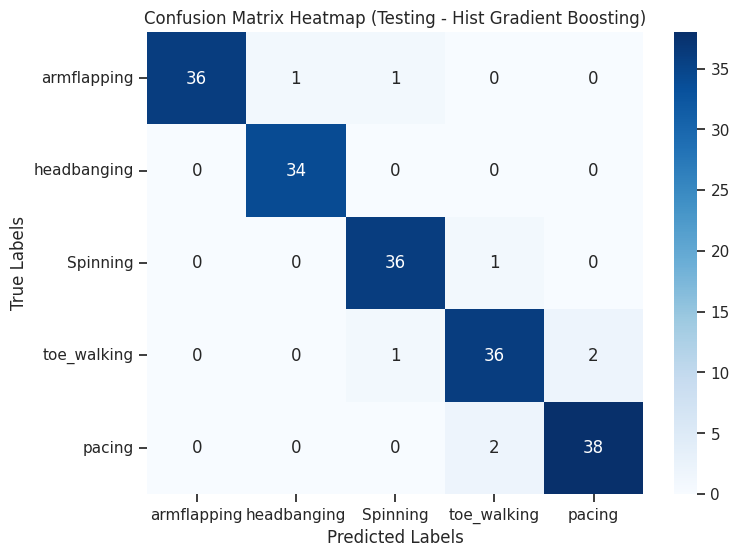


=== Metrics for Model: AdaBoosting ===

Training Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.77      0.82      0.79       154
 headbanging       0.80      0.59      0.68       135
    Spinning       0.64      0.75      0.69       146
 toe_walking       0.74      0.77      0.76       159
      pacing       0.70      0.68      0.69       158

    accuracy                           0.72       752
   macro avg       0.73      0.72      0.72       752
weighted avg       0.73      0.72      0.72       752



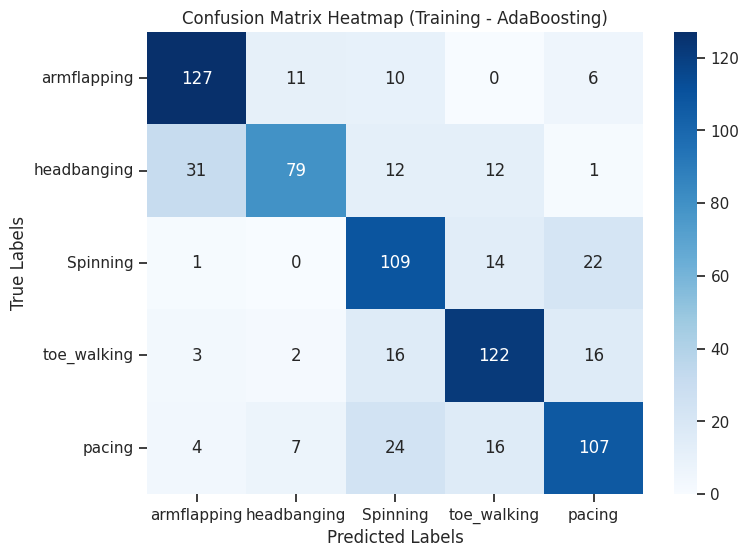


Testing Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.68      0.79      0.73        38
 headbanging       0.83      0.56      0.67        34
    Spinning       0.53      0.73      0.61        37
 toe_walking       0.63      0.67      0.65        39
      pacing       0.69      0.50      0.58        40

    accuracy                           0.65       188
   macro avg       0.67      0.65      0.65       188
weighted avg       0.67      0.65      0.65       188



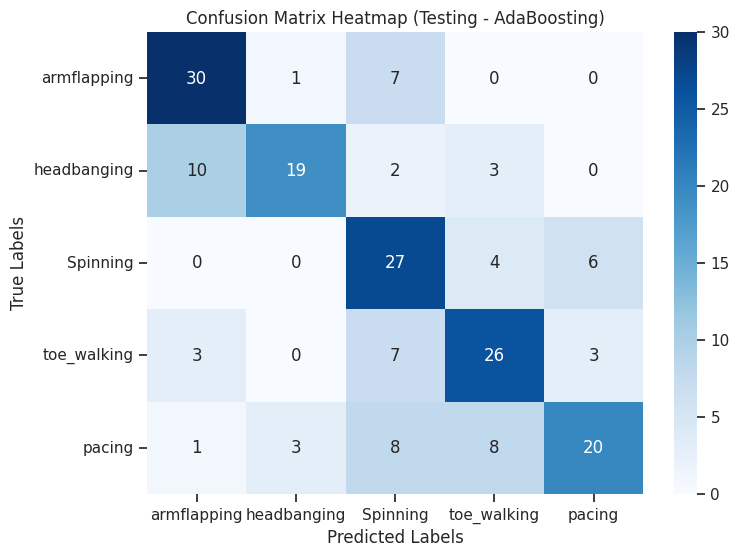


=== Metrics for Model: MLP ===

Training Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.92      0.94      0.93       154
 headbanging       0.92      0.94      0.93       135
    Spinning       0.98      0.96      0.97       146
 toe_walking       0.96      0.94      0.95       159
      pacing       0.92      0.92      0.92       158

    accuracy                           0.94       752
   macro avg       0.94      0.94      0.94       752
weighted avg       0.94      0.94      0.94       752



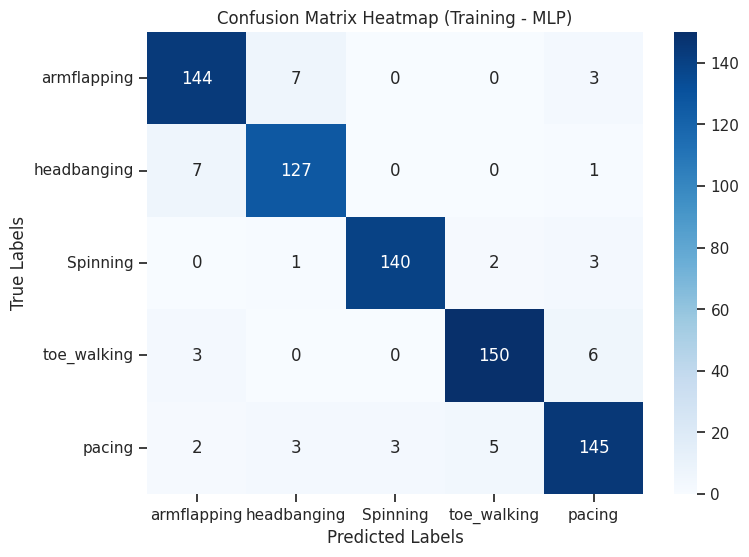


Testing Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       0.82      0.84      0.83        38
 headbanging       0.91      0.94      0.93        34
    Spinning       0.89      0.89      0.89        37
 toe_walking       0.95      0.90      0.92        39
      pacing       0.85      0.85      0.85        40

    accuracy                           0.88       188
   macro avg       0.88      0.88      0.88       188
weighted avg       0.88      0.88      0.88       188



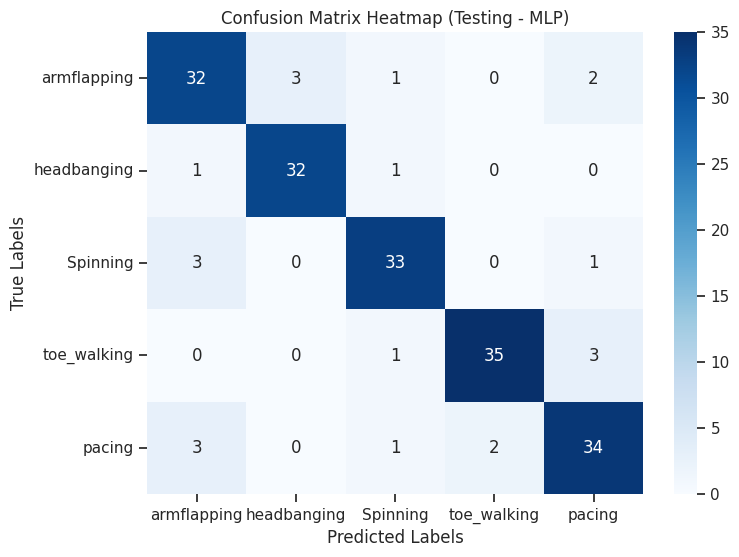


=== Metrics for Model: XGBoost ===

Training Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       1.00      1.00      1.00       154
 headbanging       1.00      1.00      1.00       135
    Spinning       1.00      1.00      1.00       146
 toe_walking       1.00      1.00      1.00       159
      pacing       1.00      1.00      1.00       158

    accuracy                           1.00       752
   macro avg       1.00      1.00      1.00       752
weighted avg       1.00      1.00      1.00       752



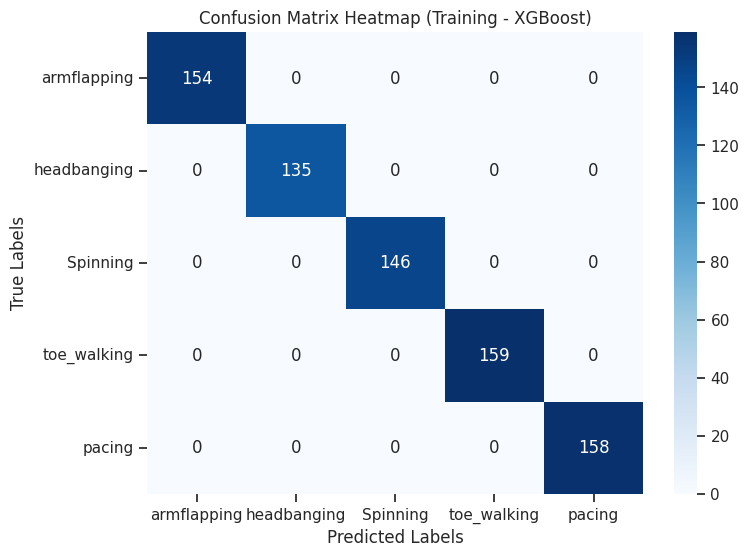


Testing Metrics:
Classification Report:
              precision    recall  f1-score   support

 armflapping       1.00      0.92      0.96        38
 headbanging       0.97      1.00      0.99        34
    Spinning       0.92      0.97      0.95        37
 toe_walking       0.93      0.97      0.95        39
      pacing       0.97      0.93      0.95        40

    accuracy                           0.96       188
   macro avg       0.96      0.96      0.96       188
weighted avg       0.96      0.96      0.96       188



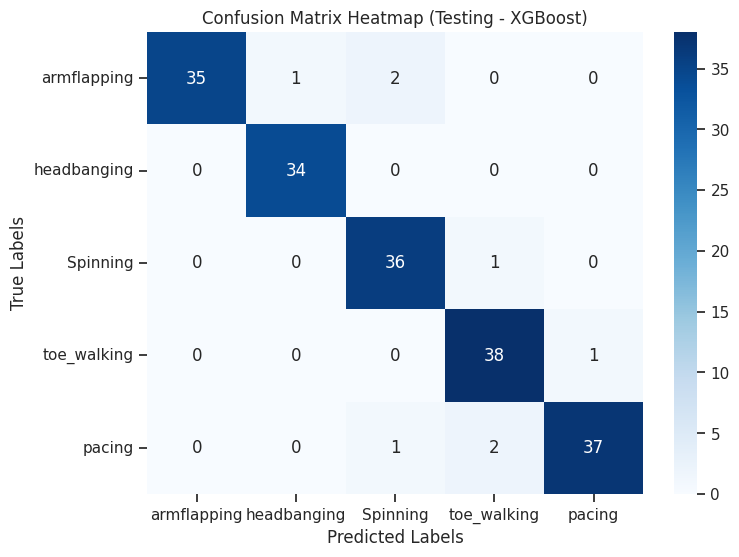

In [ ]:
# Assuming predictions_dict from the train_ML_algorithms function
display_metrics(y_train,y_test, predictions_dict)


In [ ]:
# # Use the trained models returned by the function
# trained_models = models  # Or, if train_ML_algorithms returned models separately, use that

# print("=== Generalization Gap for All Models ===")
# for name, model in trained_models.items():
#     train_acc = model.score(X_train_pca, y_train)
#     test_acc = model.score(X_test_pca, y_test)
#     gap = train_acc - test_acc
#     print(f"{name:25s} | Train: {train_acc:.3f} | Test: {test_acc:.3f} | Gap: {gap:.3f}")


In [ ]:
import joblib
import os

# Create a directory to save models
os.makedirs("saved_models_all4", exist_ok=True)

# Save each trained model
for name, model in models.items():
    joblib.dump(model, f"saved_models_all4/{name}.joblib")
    print(f"Model {name} saved successfully!")


Model Logistic Regression saved successfully!
Model SGD saved successfully!
Model K Nearest Neighbors saved successfully!
Model Support Vector Machine saved successfully!
Model Decision Tree saved successfully!
Model Random Forest saved successfully!
Model Bagging saved successfully!
Model Gradient Boosting saved successfully!
Model Hist Gradient Boosting saved successfully!
Model AdaBoosting saved successfully!
Model MLP saved successfully!
Model XGBoost saved successfully!


In [ ]:
# d2= pd.read_csv('Augment Models accuracy with Robustscaller All points.csv')


In [ ]:
# d2

In [ ]:

joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [ ]:
joblib.dump(pca, 'PCA.joblib')

['PCA.joblib']

In [ ]:
# scaler = joblib.load('scaler.joblib')
# pca = joblib.load('PCA.joblib')

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Plot boxplots for a few features
# plt.figure(figsize=(16, 6))
# sns.boxplot(data=df.iloc[:, :-1], orient='h')  # exclude target column
# plt.title('Boxplot of Features to Identify Outliers')
# plt.show()


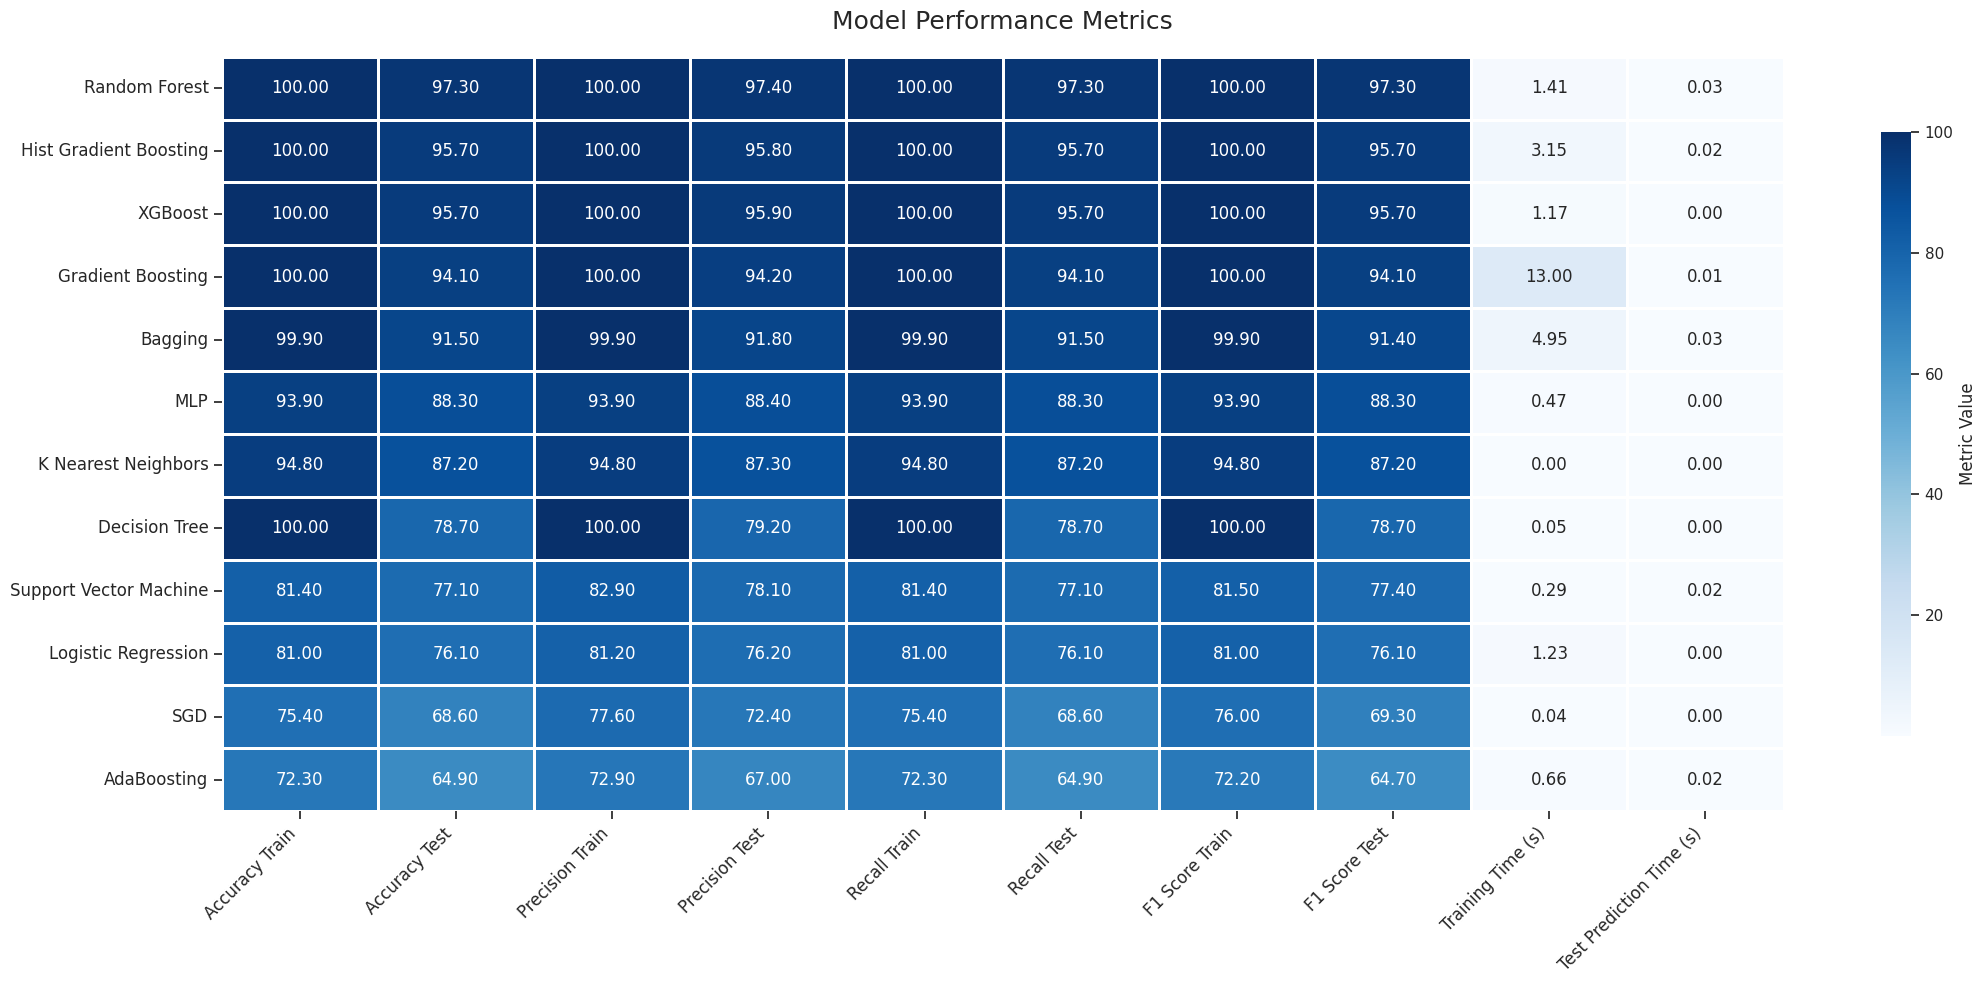

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22, 10))

sns.heatmap(
    Model_accuracy,
    annot=True,
    linewidths=1,
    linecolor='white',
    fmt=".2f",
    cmap="Blues",   # 🎨 اللون Light Blue
    cbar_kws={"shrink": 0.8, "label": "Metric Value"}
)

plt.title("Model Performance Metrics", fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()
